# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
df = pd.read_csv('aviation_accidents_clean.csv', encoding="utf-8")
df

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7240\3460009817.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('aviation_accidents_clean.csv', encoding="utf-8")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Event.Year,Total_Passengers,SeriousFatal_Rate,Destroyed,Plane_ID
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,588.0,VMC,TAXI,Probable Cause,04-12-2014,1983,NaN,NaN,0,BOEING_747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,NaN,IMC,CRUISE,Probable Cause,02-05-2011,1983,NaN,NaN,1,PIPER_PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,4.0,VMC,STANDING,Probable Cause,17-10-2016,1983,NaN,NaN,0,DE HAVILLAND_DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,100.0,VMC,TAXI,Probable Cause,11-06-2018,1983,NaN,NaN,0,BOEING_727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,1.0,VMC,CLIMB,Probable Cause,05-05-2011,1983,NaN,NaN,0,BEECH_C35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17874,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,1.0,VMC,NAN,NaN,15-12-2022,2022,1.0,0.0,0,CESSNA_172
17875,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,1.0,NAN,NAN,NaN,14-12-2022,2022,1.0,0.0,0,PIPER_PA42
17876,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,1.0,VMC,NAN,NaN,27-12-2022,2022,1.0,0.0,0,CIRRUS DESIGN CORP_SR22
17877,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,0.0,VMC,NAN,NaN,23-12-2022,2022,1.0,1.0,0,CESSNA_R172K


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [6]:
df["Small_Aircraft"] = df["Total_Passengers"] < 20
df

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Event.Year,Total_Passengers,SeriousFatal_Rate,Destroyed,Plane_ID,Small_Aircraft
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,VMC,TAXI,Probable Cause,04-12-2014,1983,NaN,NaN,0,BOEING_747,False
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,IMC,CRUISE,Probable Cause,02-05-2011,1983,NaN,NaN,1,PIPER_PA-28-140,False
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,VMC,STANDING,Probable Cause,17-10-2016,1983,NaN,NaN,0,DE HAVILLAND_DHC-6,False
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,VMC,TAXI,Probable Cause,11-06-2018,1983,NaN,NaN,0,BOEING_727-200,False
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,VMC,CLIMB,Probable Cause,05-05-2011,1983,NaN,NaN,0,BEECH_C35,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17874,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,VMC,NAN,NaN,15-12-2022,2022,1.0,0.0,0,CESSNA_172,True
17875,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NAN,NAN,NaN,14-12-2022,2022,1.0,0.0,0,PIPER_PA42,True
17876,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,VMC,NAN,NaN,27-12-2022,2022,1.0,0.0,0,CIRRUS DESIGN CORP_SR22,True
17877,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,VMC,NAN,NaN,23-12-2022,2022,1.0,1.0,0,CESSNA_R172K,True


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

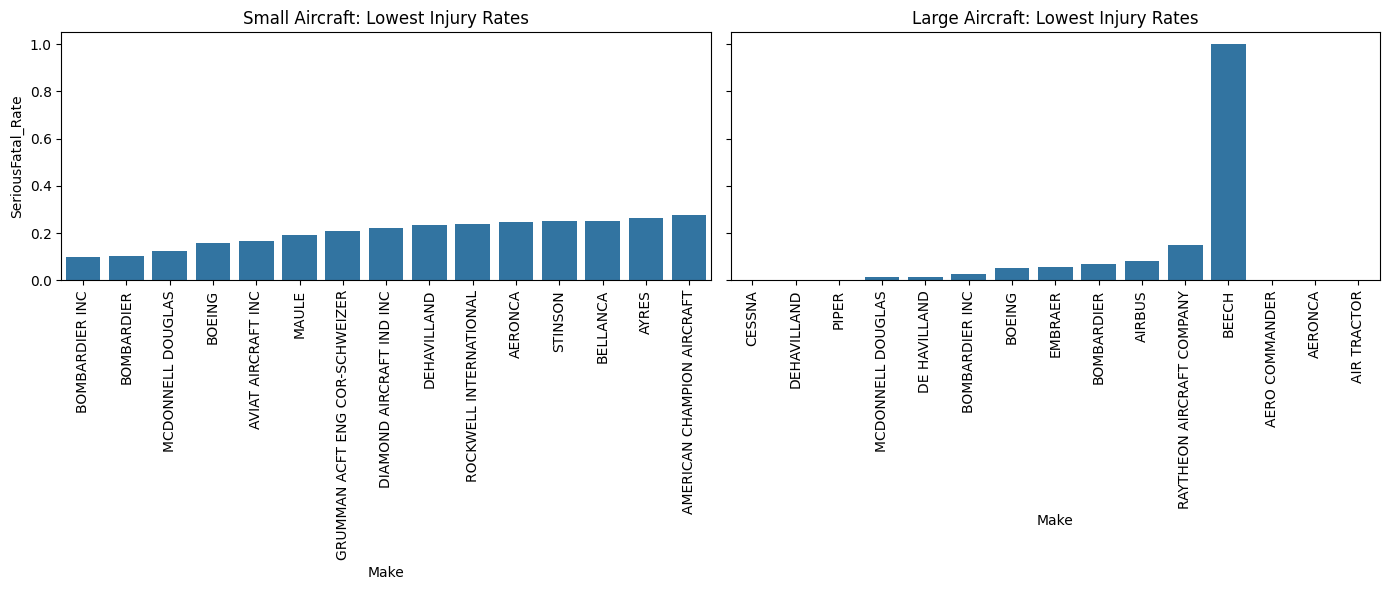

In [7]:
# Mean serious/fatal injury fraction by make
make_injury = df.groupby(["Make","Small_Aircraft"])["SeriousFatal_Rate"].mean().reset_index()

# Top 15 safest makes per group
small_safest = make_injury[make_injury["Small_Aircraft"]==True].nsmallest(15,"SeriousFatal_Rate")
large_safest = make_injury[make_injury["Small_Aircraft"]==False].nsmallest(15,"SeriousFatal_Rate")

# Plot side-by-side
fig, axes = plt.subplots(1,2,figsize=(14,6),sharey=True)
sns.barplot(x="Make", y="SeriousFatal_Rate", data=small_safest, ax=axes[0])
axes[0].set_title("Small Aircraft: Lowest Injury Rates")
axes[0].tick_params(axis="x", rotation=90)

sns.barplot(x="Make", y="SeriousFatal_Rate", data=large_safest, ax=axes[1])
axes[1].set_title("Large Aircraft: Lowest Injury Rates")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

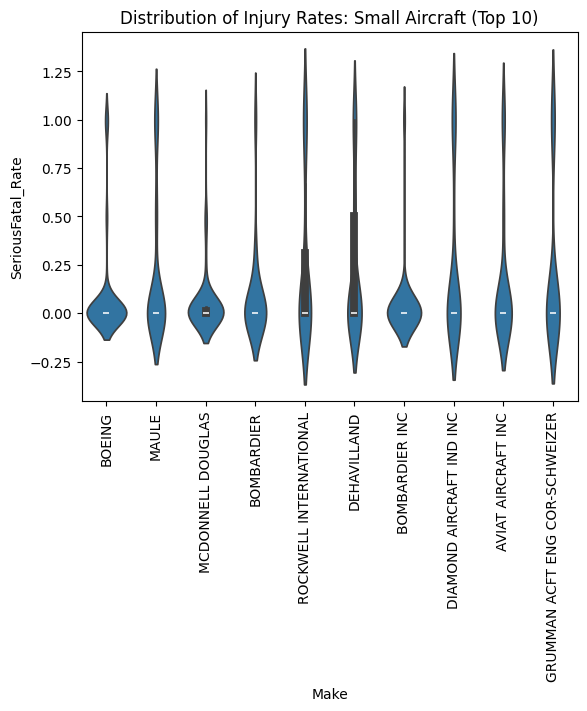

In [8]:
# Violinplot for small aircraft (10 lowest)
small_top10 = make_injury[make_injury["Small_Aircraft"]==True].nsmallest(10,"SeriousFatal_Rate")
sns.violinplot(x="Make", y="SeriousFatal_Rate", data=df[df["Make"].isin(small_top10["Make"])])
plt.title("Distribution of Injury Rates: Small Aircraft (Top 10)")
plt.xticks(rotation=90)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

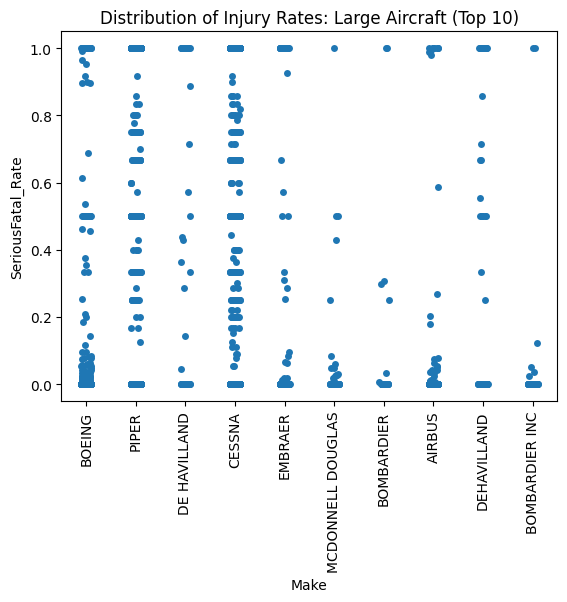

In [9]:
# Stripplot for large aircraft (10 lowest)
large_top10 = make_injury[make_injury["Small_Aircraft"]==False].nsmallest(10,"SeriousFatal_Rate")
sns.stripplot(x="Make", y="SeriousFatal_Rate", data=df[df["Make"].isin(large_top10["Make"])], jitter=True)
plt.title("Distribution of Injury Rates: Large Aircraft (Top 10)")
plt.xticks(rotation=90)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [12]:
make_damage = df.groupby(["Make","Small_Aircraft"])["Destroyed"].mean().reset_index()
small_damage = make_damage[make_damage["Small_Aircraft"]==True].nsmallest(15,"Destroyed")
large_damage = make_damage[make_damage["Small_Aircraft"]==False].nsmallest(15,"Destroyed")
print(make_damage)
print(small_damage)
print(large_damage)

              Make  Small_Aircraft  Destroyed
0   AERO COMMANDER           False   0.428571
1   AERO COMMANDER            True   0.092105
2          AERONCA           False   0.000000
3          AERONCA            True   0.041667
4      AIR TRACTOR           False   0.069767
..             ...             ...        ...
64          SOCATA            True   0.214286
65         STINSON           False   0.058824
66         STINSON            True   0.017857
67     TAYLORCRAFT           False   0.050000
68     TAYLORCRAFT            True   0.027397

[69 rows x 3 columns]
                              Make  Small_Aircraft  Destroyed
46  GRUMMAN ACFT ENG COR-SCHWEIZER            True   0.017241
48                        LUSCOMBE            True   0.017391
66                         STINSON            True   0.017857
9                           AIRBUS            True   0.024590
68                     TAYLORCRAFT            True   0.027397
22                          BOEING            True   

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The large aircarft have a significantly lower rate of being destroyed as well as lower rates of injury with the top three safest being Boieng, Airbus and Bombardier. As for smaller aircraft, they have a significantly higher rate of destruction as compared to the large aircraft and a higher distribution of injuries too. The top three safest however are: Airbus, Boieng and McDonell Douglas.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Mean injury for both large and small aircrafts**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

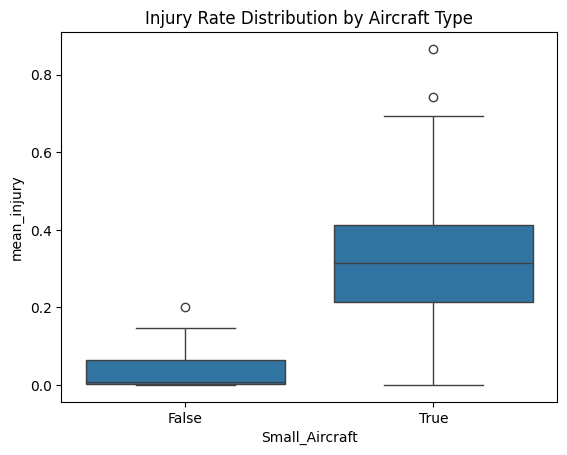

In [13]:
# Mean injury rate by Plane_ID
plane_injury = df.groupby(["Plane_ID","Small_Aircraft"]).agg(
    mean_injury=("SeriousFatal_Rate","mean"),
    n_accidents=("Plane_ID","count")
).reset_index()

# Filter for robustness (≥10 accidents per type)
plane_injury = plane_injury[plane_injury["n_accidents"] >= 10]

# Plot distributions
sns.boxplot(x="Small_Aircraft", y="mean_injury", data=plane_injury)
plt.title("Injury Rate Distribution by Aircraft Type")
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The fraction of mean injury is significantly lower in large aircraft which have been marked by false in the boxplot above as compared to the small aircraft. This is even evidence by the outliers which fall below the avaerage mean injury of the small aircraft. This implies that large aircarft are significantly safer than small aircraft.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather Conditions

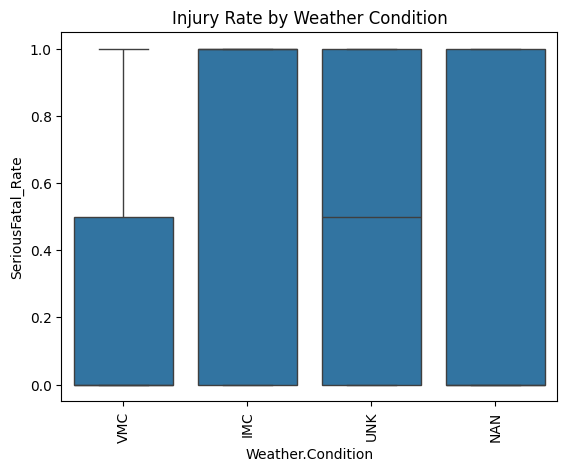

In [21]:
sns.boxplot(x="Weather.Condition", y="SeriousFatal_Rate", data=df)
plt.xticks(rotation=90)
plt.title("Injury Rate by Weather Condition")
plt.show()

As shown in the boxplot above, the most serious Fatal rates occur when accidents occur during the IMC and UNK weather as compared to VMC.

Phase of flight

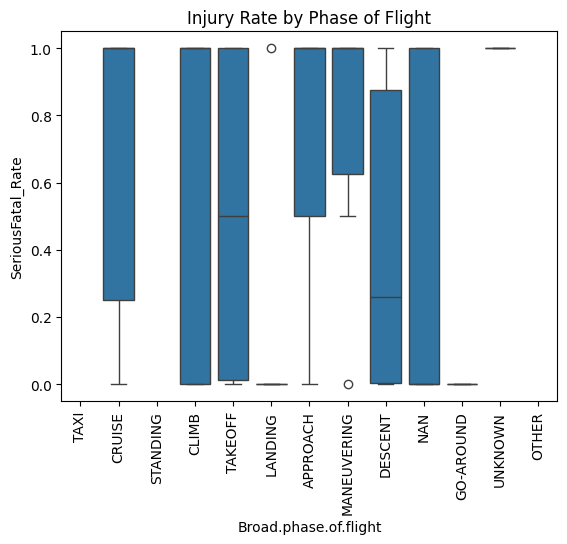

In [22]:
sns.boxplot(x="Broad.phase.of.flight", y="SeriousFatal_Rate", data=df)
plt.xticks(rotation=90)
plt.title("Injury Rate by Phase of Flight")
plt.show()

Upon analysis and as shown in the box plot above, accidents with the most serious fatarate occur during climb and take-off phases of the flight.